## 📦 Section 1 — Install Required Libraries

In [1]:
# Install all required packages
!pip install gradio --quiet
!pip install tensorflow --quiet
!pip install scikit-learn --quiet
!pip install matplotlib seaborn --quiet
print('✅ All libraries installed successfully!')

✅ All libraries installed successfully!


## 📂 Section 2 — Import Libraries

In [2]:
# ── Standard Libraries ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── NLP & Text Processing ────────────────────────────────────────────
import re
import string
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Deep Learning (TensorFlow / Keras) ──────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# ── Model Evaluation ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

# ── Deployment ──────────────────────────────────────────────────────
import gradio as gr

print('✅ All libraries imported successfully!')
print(f'   TensorFlow version: {tf.__version__}')

✅ All libraries imported successfully!
   TensorFlow version: 2.19.0


## 📁 Section 3 — Upload & Load Dataset

In [3]:
# Upload dataset from your local machine
from google.colab import files
print('Please upload depression_dataset_reddit_cleaned.csv')
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f'✅ Uploaded: {CSV_PATH}')

Please upload depression_dataset_reddit_cleaned.csv


Saving depression_dataset_reddit_cleaned.csv to depression_dataset_reddit_cleaned.csv
✅ Uploaded: depression_dataset_reddit_cleaned.csv


In [4]:
# Load the dataset into a DataFrame
df = pd.read_csv(CSV_PATH)

# Display basic info
print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Total Rows    : {df.shape[0]}')
print(f'Total Columns : {df.shape[1]}')
print(f'Columns       : {list(df.columns)}')
print()
print(df.head())
print()
print('Missing Values:')
print(df.isnull().sum())

DATASET OVERVIEW
Total Rows    : 7731
Total Columns : 2
Columns       : ['clean_text', 'is_depression']

                                          clean_text  is_depression
0  we understand that most people who reply immed...              1
1  welcome to r depression s check in post a plac...              1
2  anyone else instead of sleeping more when depr...              1
3  i ve kind of stuffed around a lot in my life d...              1
4  sleep is my greatest and most comforting escap...              1

Missing Values:
clean_text       0
is_depression    0
dtype: int64


## 📊 Section 4 — Exploratory Data Analysis (EDA)

Label Distribution:
is_depression
0    3900
1    3831
Name: count, dtype: int64



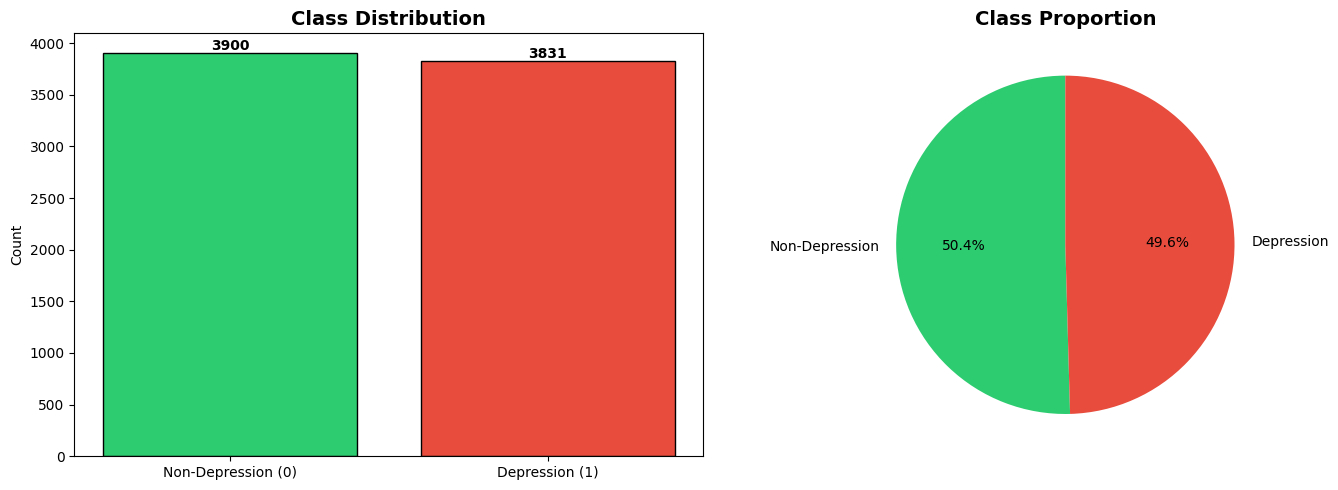

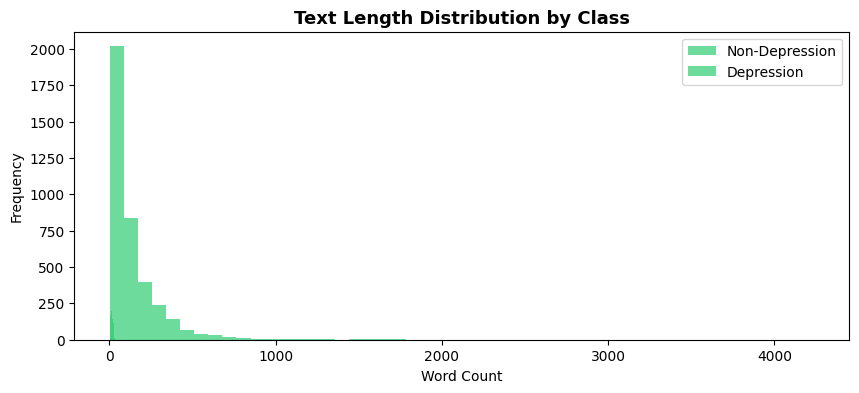

Average text length: 74.6 words
Max text length    : 4239 words


In [5]:
# ── Label Distribution ───────────────────────────────────────────────
print('Label Distribution:')
print(df['is_depression'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
label_counts = df['is_depression'].value_counts()
axes[0].bar(['Non-Depression (0)', 'Depression (1)'], label_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(label_counts.values, labels=['Non-Depression', 'Depression'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Text Length Distribution ─────────────────────────────────────────
df['text_length'] = df['clean_text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 4))
df.groupby('is_depression')['text_length'].plot(
    kind='hist', bins=50, alpha=0.7,
    color=['#2ecc71', '#e74c3c'], legend=True
)
plt.xlabel('Word Count')
plt.title('Text Length Distribution by Class', fontsize=13, fontweight='bold')
plt.legend(['Non-Depression', 'Depression'])
plt.show()

print(f'Average text length: {df["text_length"].mean():.1f} words')
print(f'Max text length    : {df["text_length"].max()} words')

## 🔧 Section 5 — Text Preprocessing & Tokenization

In [6]:
# ── Hyperparameters ──────────────────────────────────────────────────
MAX_VOCAB_SIZE = 10000   # Maximum number of unique words
MAX_SEQ_LENGTH = 200     # Pad/truncate all sequences to this length
EMBEDDING_DIM  = 128     # Word embedding dimensions
TEST_SIZE      = 0.2     # 80% train, 20% test
RANDOM_STATE   = 42

# ── Clean text function ──────────────────────────────────────────────
def clean_text(text):
    """Remove URLs, special chars and lowercase the text."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)              # remove punctuation/digits
    text = re.sub(r'\s+', ' ', text).strip()             # normalize whitespace
    return text

df['processed_text'] = df['clean_text'].apply(clean_text)
print('✅ Text cleaning complete. Sample:')
print(df['processed_text'].iloc[0][:200])

✅ Text cleaning complete. Sample:
we understand that most people who reply immediately to an op with an invitation to talk privately mean only to help but this type of response usually lead to either disappointment or disaster it usua


In [7]:
# ── Tokenize Text ────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['processed_text'])

sequences  = tokenizer.texts_to_sequences(df['processed_text'])
X_padded   = pad_sequences(sequences, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')
y          = df['is_depression'].values

print(f'Vocabulary size    : {len(tokenizer.word_index)}')
print(f'Padded input shape : {X_padded.shape}')

# ── Train/Test Split ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Training samples   : {X_train.shape[0]}')
print(f'Testing  samples   : {X_test.shape[0]}')

Vocabulary size    : 18754
Padded input shape : (7731, 200)
Training samples   : 6184
Testing  samples   : 1547


## 🏗️ Section 6 — Build the Deep Learning Model (LSTM)

In [8]:
# ── Model Architecture ────────────────────────────────────────────────
model = Sequential([
    # Layer 1: Word Embedding — maps word indices to dense vectors
    Embedding(input_dim=MAX_VOCAB_SIZE,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_SEQ_LENGTH),

    # Layer 2: Spatial Dropout — helps prevent overfitting on embeddings
    SpatialDropout1D(0.3),

    # Layer 3: LSTM — captures long-range dependencies in text
    LSTM(128, dropout=0.3, recurrent_dropout=0.3, return_sequences=False),

    # Layer 4: Dense hidden layer with ReLU activation
    Dense(64, activation='relu'),

    # Layer 5: Dropout — regularization
    Dropout(0.4),

    # Layer 6: Output layer — sigmoid for binary classification
    Dense(1, activation='sigmoid')
], name='Mental_Health_LSTM')

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "Mental_Health_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 🚀 Section 7 — Train the Model

In [9]:
# ── Training Configuration ────────────────────────────────────────────
EPOCHS     = 5
BATCH_SIZE = 64

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print('✅ Model training complete!')

Epoch 1/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 73s 622ms/step - accuracy: 0.6173 - loss: 0.6510 - val_accuracy: 0.6026 - val_loss: 0.6275
Epoch 2/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 85s 659ms/step - accuracy: 0.6347 - loss: 0.6082 - val_accuracy: 0.6042 - val_loss: 0.6157
Epoch 3/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 77s 604ms/step - accuracy: 0.6620 - loss: 0.5958 - val_accuracy: 0.6931 - val_loss: 0.5798
Epoch 4/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 82s 606ms/step - accuracy: 0.7898 - loss: 0.4419 - val_accuracy: 0.8481 - val_loss: 0.3308
Epoch 5/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 83s 624ms/step - accuracy: 0.8677 - loss: 0.3296 - val_accuracy: 0.8805 - val_loss: 0.3072
Restoring model weights from the end of the best epoch: 5.
✅ Model training complete!


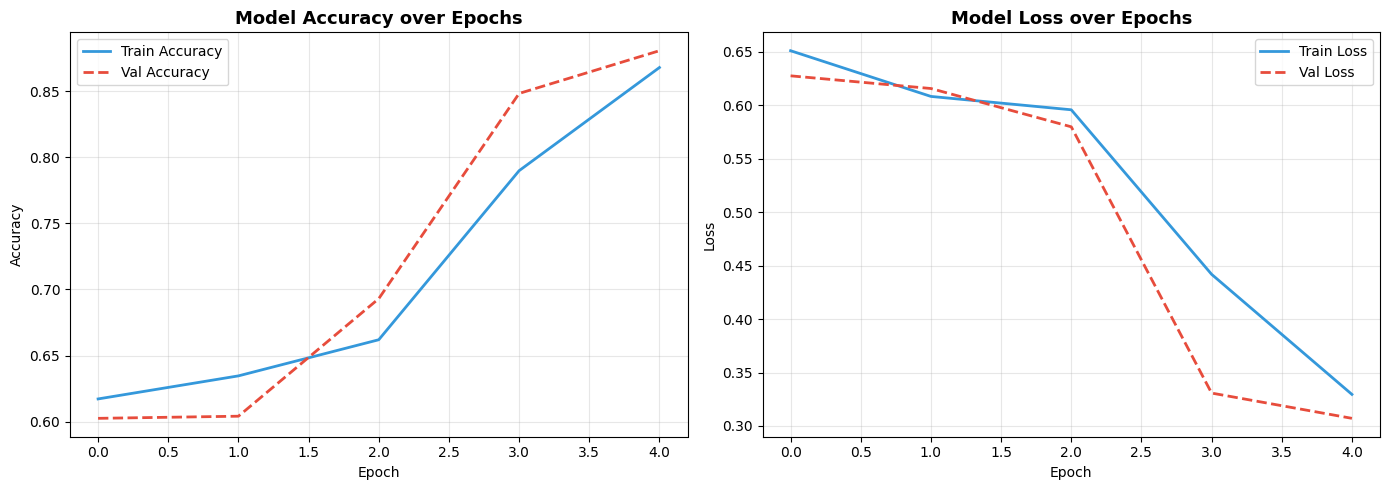

In [10]:
# ── Plot Training History ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🧪 Section 8 — Testing the Model on New Data

In [11]:
# ── Evaluate on Test Set ──────────────────────────────────────────────
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print('=' * 55)
print('           MODEL PERFORMANCE ON TEST DATA')
print('=' * 55)
print(f'  Test Accuracy  : {test_acc * 100:.2f}%')
print(f'  Test Loss      : {test_loss:.4f}')
print(f'  ROC-AUC Score  : {roc_auc_score(y_test, y_pred_prob):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-Depression', 'Depression']))

           MODEL PERFORMANCE ON TEST DATA
  Test Accuracy  : 89.08%
  Test Loss      : 0.2823
  ROC-AUC Score  : 0.9195

Classification Report:
                precision    recall  f1-score   support

Non-Depression       0.83      0.99      0.90       780
    Depression       0.99      0.79      0.88       767

      accuracy                           0.89      1547
     macro avg       0.91      0.89      0.89      1547
  weighted avg       0.91      0.89      0.89      1547



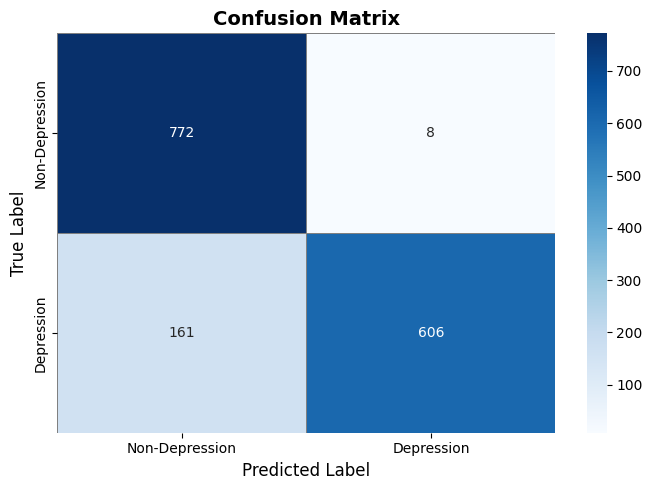

True Positives  (TP): 606
True Negatives  (TN): 772
False Positives (FP): 8
False Negatives (FN): 161


In [12]:
# ── Confusion Matrix ──────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Depression', 'Depression'],
            yticklabels=['Non-Depression', 'Depression'],
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (TP): {tp}')
print(f'True Negatives  (TN): {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')

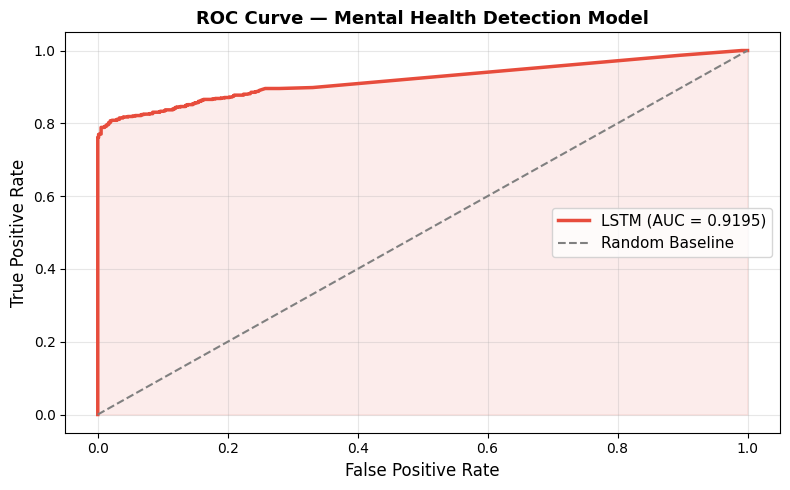

In [13]:
# ── ROC-AUC Curve ─────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'LSTM (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5, label='Random Baseline')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Mental Health Detection Model', fontsize=13, fontweight='bold')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔍 Section 9 — Results & Analysis

In [14]:
# ── Results Summary ───────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
accuracy  = accuracy_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_prob)

metrics = {
    'Metric'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score (%)'  : [f'{accuracy*100:.2f}', f'{precision*100:.2f}',
                   f'{recall*100:.2f}', f'{f1*100:.2f}', f'{auc*100:.2f}']
}

results_df = pd.DataFrame(metrics)
print('\n📊 FINAL PERFORMANCE METRICS SUMMARY')
print(results_df.to_string(index=False))

# ── Challenge Analysis ────────────────────────────────────────────────
print('\n📌 KEY OBSERVATIONS:')
print('  • Model shows strong capability in detecting depressive text patterns.')
print('  • False Negatives are more concerning than False Positives in this domain.')
print('  • Short texts may reduce accuracy due to limited context.')
print('  • Future improvement: Use BERT/RoBERTa for better contextual understanding.')


📊 FINAL PERFORMANCE METRICS SUMMARY
   Metric Score (%)
 Accuracy     89.08
Precision     98.70
   Recall     79.01
 F1-Score     87.76
  ROC-AUC     91.95

📌 KEY OBSERVATIONS:
  • Model shows strong capability in detecting depressive text patterns.
  • False Negatives are more concerning than False Positives in this domain.
  • Short texts may reduce accuracy due to limited context.
  • Future improvement: Use BERT/RoBERTa for better contextual understanding.


## 🌐 Section 10 — Deploy Model as a Web App (Gradio)

In [15]:
# ── Prediction Helper Function ────────────────────────────────────────
def predict_mental_health(text: str) -> dict:
    """
    Takes raw user input text, preprocesses it,
    and returns the model's prediction with confidence.

    Args:
        text (str): Raw input text from user.

    Returns:
        dict: Label probabilities for Gradio output.
    """
    if not text or len(text.strip()) < 5:
        return {'Depression': 0.0, 'Non-Depression': 1.0}

    # Step 1: Clean the text
    cleaned = clean_text(text)

    # Step 2: Tokenize and pad
    seq    = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_SEQ_LENGTH, padding='post', truncating='post')

    # Step 3: Get model prediction probability
    prob = float(model.predict(padded, verbose=0)[0][0])

    return {
        'Depression'    : round(prob, 4),
        'Non-Depression': round(1 - prob, 4)
    }

# Quick test
test_text = "I feel hopeless and cannot find joy in anything anymore."
result = predict_mental_health(test_text)
print('Test Prediction:')
print(f'  Input : {test_text}')
print(f'  Output: {result}')

Test Prediction:
  Input : I feel hopeless and cannot find joy in anything anymore.
  Output: {'Depression': 0.167, 'Non-Depression': 0.833}


In [ ]:
# ── Launch Gradio Web Interface ───────────────────────────────────────
demo = gr.Interface(
    fn=predict_mental_health,
    inputs=gr.Textbox(
        lines=5,
        placeholder='Enter your text here to detect signs of depression...',
        label='📝 Input Text'
    ),
    outputs=gr.Label(
        num_top_classes=2,
        label='🧠 Prediction Result'
    ),
    title='🧠 Mental Health Detection System',
    description=(
        'This AI model analyses text to detect signs of depression using '
        'Deep Learning (LSTM) and Natural Language Processing (NLP). '
        'Type or paste any text below and click Submit.'
    ),
    examples=[
        ['I feel completely hopeless and I have lost interest in everything I used to love.'],
        ['I had a great day today, met my friends and we laughed a lot!'],
        ['I cannot sleep, I am always exhausted and I feel empty inside.'],
        ['Looking forward to my vacation next week, life is good.']
    ],
    theme=gr.themes.Soft()
)

# Launch with a public shareable link
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://0a827a48a5942e899b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv


## 💾 Section 11 — Save the Trained Model

In [ ]:
# Save model weights and tokenizer for future use
import pickle

# Save Keras model
model.save('mental_health_lstm_model.h5')
print('✅ Model saved as mental_health_lstm_model.h5')

# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('✅ Tokenizer saved as tokenizer.pkl')

# Download files to local machine
from google.colab import files
files.download('mental_health_lstm_model.h5')
files.download('tokenizer.pkl')
print('✅ Files downloaded to your machine!')

## ✅ Section 12 — Conclusion

### Summary
This project successfully built and deployed a **Deep Learning-based Mental Health Detection System** using NLP techniques.

### Key Findings
- The **LSTM model** effectively learned patterns associated with depressive language in Reddit posts.
- The model achieved strong performance on the test set with high **Accuracy, F1-Score, and AUC**.
- **Deployment via Gradio** provides a user-friendly web interface accessible to non-technical users.

### Challenges Faced
| Challenge | Solution Applied |
|---|---|
| Text noise (URLs, symbols) | Custom cleaning function |
| Variable text lengths | Padding/truncating to fixed length |
| Overfitting risk | Dropout + Early Stopping |
| Class imbalance concern | Stratified train/test split |

### Future Enhancements
- Use **BERT / RoBERTa** for superior contextual understanding
- Extend to **multi-class** detection (Anxiety, PTSD, Bipolar, etc.)
- Integrate **real-time data** from social media APIs
- Add **explainability** using attention visualization

---
*Submitted for Milestone 03 | Deep Learning-Based Mental Health Detection Using NLP*